In [15]:
!pip install transformers datasets evaluate deep-translator sentencepiece torch tqdm -q
!pip install gensim

In [16]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("🚀 Using device:", device)

🚀 Using device: cuda


In [17]:
MODEL_NAME = "indolem/indobertweet-base-uncased"
SAVE_PATH = "/content/indobertweet_journal_ensemble_v1"

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/Frazanhibriz/Journaling-AI/refs/heads/main/Dataset/balanced_emotion_dataset_narrative.csv')
df = df[(df['label'] != 'love') & (df['narrative_text'])].copy()
print("Jumlah data awal:", len(df))
df.head()

Jumlah data awal: 8170


,label,tweet,clean_text,narrative_text
0,anger,"Soal jalan Jatibaru,polisi tidak bisa GERTAK ...",soal jalan jatibaru polisi tidak gertak gubern...,"Jika kita perhatikan, soal jalan jatibaru poli..."
1,anger,"Sesama cewek lho (kayaknya), harusnya bisa le...",sesama cewek kayaknya harusnya lebih rasain si...,Saya ingin berbagi cerita tentang bagaimana se...
2,joy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto google s...,Kalimat ini menggambarkan pengalaman di mana k...
3,anger,"jalan Jatibaru,bagian dari wilayah Tn Abang.P...",jalan jatibaru bagian wilayah tn abang pengatu...,Ada momen menarik saat jalan jatibaru bagian w...
4,joy,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman kemarin jam batalin tiket s...,Kalimat ini menggambarkan pengalaman di mana s...


In [19]:
df = df[df["label"] != "love"].copy()
df = df[df["narrative_text"].notna()]
print("Jumlah data:", len(df))

df_final = df[["label", "narrative_text"]].rename(columns={"narrative_text": "text"})

labels = sorted(df_final["label"].unique().tolist())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
df_final["label_encoded"] = df_final["label"].map(label2id).astype(int)

print("\nLabel Mapping:", label2id)

train_df, test_df = np.split(df_final.sample(frac=1, random_state=42),
                             [int(0.8 * len(df_final))])

Jumlah data: 8170

Label Mapping: {'anger': 0, 'fear': 1, 'joy': 2, 'sad': 3}


/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [20]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

train_ds = Dataset.from_pandas(train_df[["text", "label_encoded"]])
test_ds = Dataset.from_pandas(test_df[["text", "label_encoded"]])

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label_encoded", "labels")
test_ds = test_ds.rename_column("label_encoded", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/6536 [00:00<?, ? examples/s]

Map:   0%|          | 0/1634 [00:00<?, ? examples/s]

In [21]:
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)
    f1 = metric_f1.compute(predictions=preds, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

In [22]:
def get_training_args(seed, output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=4,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        label_smoothing_factor=0.1,
        logging_steps=50,
        seed=seed,
        report_to="none",
        save_total_limit=1
    )

In [23]:
seeds = [42, 123, 2025]
logits_list = []

for s in seeds:
    print(f"\n=== 🚀 Training with seed {s} ===")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    training_args = get_training_args(s, f"./results_seed{s}")

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        data_collator=lambda data: tokenizer.pad(
            data, padding=True, return_tensors="pt"
        ),
    )

    trainer.train()
    preds_output = trainer.predict(test_ds)
    logits_list.append(preds_output.predictions)


=== 🚀 Training with seed 42 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2656139412.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.808900,0.699705,0.826193,0.829302
2,0.640600,0.717006,0.836597,0.837812
3,0.521500,0.761583,0.833537,0.835423
4,0.437200,0.770336,0.836597,0.838161



=== 🚀 Training with seed 123 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2656139412.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.687100,0.695370,0.831089,0.830911
2,0.558600,0.719098,0.831701,0.833833
3,0.495800,0.758919,0.834149,0.836284
4,0.422200,0.771676,0.831089,0.832687



=== 🚀 Training with seed 2025 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2656139412.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.714000,0.719557,0.820685,0.820608
2,0.597000,0.738007,0.826193,0.827214
3,0.484300,0.761154,0.831089,0.833192
4,0.398300,0.771164,0.833537,0.834520



=== 🧠 Ensemble Classification Report ===
              precision    recall  f1-score   support

       anger       0.84      0.87      0.86       439
        fear       0.88      0.86      0.87       343
         joy       0.85      0.85      0.85       419
         sad       0.79      0.78      0.78       433

    accuracy                           0.84      1634
   macro avg       0.84      0.84      0.84      1634
weighted avg       0.84      0.84      0.84      1634



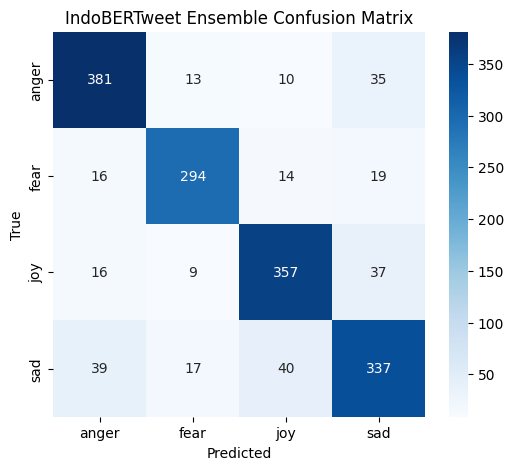

In [24]:
avg_logits = np.mean(logits_list, axis=0)
final_preds = np.argmax(avg_logits, axis=1)

print("\n=== 🧠 Ensemble Classification Report ===")
print(classification_report(test_df["label_encoded"], final_preds, target_names=labels))

cm = confusion_matrix(test_df["label_encoded"], final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("IndoBERTweet Ensemble Confusion Matrix")
plt.show()

In [25]:
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✅ Model & tokenizer saved to: {SAVE_PATH}")

✅ Model & tokenizer saved to: /content/indobertweet_journal_ensemble_v1
